# GhostCite Result Analysis

This notebook analyzes the validation results of LLM-generated citations.
Data source: `validation_results/` directory containing CSV files.
Goal: Analyze impact of Model, Online/Offline, Thinking, number of refs, and topic on citation validity (Hallucination Rate).


In [138]:
import numpy as np
import pandas as pd
import os
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [139]:
# Markdown Report Generator
class MarkdownReporter:
    """A utility class to collect analysis results and save them to a markdown file."""
    
    def __init__(self, title="GhostCite Analysis Report"):
        self.sections = []
        self.title = title
        
    def add_section(self, title, content):
        """Add a section with a title and content."""
        self.sections.append({"title": title, "content": content})
    
    def add_table(self, title, df, description=""):
        """Add a table from a DataFrame."""
        content = ""
        if description:
            content += f"{description}\n\n"
        content += df.to_markdown(index=True)
        self.add_section(title, content)
    
    def add_summary(self, title, stats_dict, description=""):
        """Add a summary section with key-value statistics."""
        content = ""
        if description:
            content += f"{description}\n\n"
        for key, value in stats_dict.items():
            if isinstance(value, float):
                content += f"- **{key}**: {value:.2f}\n"
            else:
                content += f"- **{key}**: {value}\n"
        self.add_section(title, content)
    
    def generate_markdown(self):
        """Generate the complete markdown report."""
        md = f"# {self.title}\n\n"
        md += f"*Generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}*\n\n"
        md += "---\n\n"
        
        for i, section in enumerate(self.sections, 1):
            md += f"## {section['title']}\n\n"
            md += section['content']
            md += "\n\n---\n\n"
        
        return md
    
    def save(self, filepath="analysis_report.md"):
        """Save the report to a markdown file."""
        md_content = self.generate_markdown()
        with open(filepath, 'w', encoding='utf-8') as f:
            f.write(md_content)
        print(f"Report saved to: {filepath}")
        return filepath

# Initialize the global reporter
reporter = MarkdownReporter("GhostCite: Citation Validity in the LLM Era")

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    """
    截断 colormap。
    minval: 起始百分比 (0.0 表示最浅)
    maxval: 结束百分比 (1.0 表示最深)
    """
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

# 00. Data Preprocessing

In [140]:
# ========== 使用新数据 llm_new_res.csv ==========
# 新数据包含重新计算的相似度 (similarity_correct) 和判断结果 (new_status)

def parse_file_column(file_value):
    """从 file 列解析 model, topic, num_refs, thinking, online, run"""
    # Example: deepseek_HC_20refs_thinking_online_run05_verified
    pattern = r"^(?P<model>[a-zA-Z0-9]+)_(?P<topic>[A-Z]{2})_(?P<num_refs>\d+)refs_(?P<thinking>[a-zA-Z]+)_(?P<online>[a-zA-Z]+)_run(?P<run>\d+)_verified$"
    match = re.match(pattern, str(file_value))
    if match:
        return match.groupdict()
    return None

new_data_file = "llm_new_res_v3.csv"
print(f"Loading new data from {new_data_file}...")

# Load articles from new data file
articles_df = pd.read_csv(new_data_file)
print(f"Loaded {len(articles_df)} citations for detailed analysis.")

# Parse metadata from 'file' column if needed
if 'model' not in articles_df.columns or articles_df['model'].isna().all():
    # 'file' column contains: deepseek_HC_20refs_thinking_online_run05_verified
    metadata_list = articles_df['file'].apply(parse_file_column)
    for col in ['model', 'topic', 'num_refs', 'thinking', 'online', 'run']:
        articles_df[col] = metadata_list.apply(lambda x: x[col] if x else None)
    articles_df['num_refs'] = pd.to_numeric(articles_df['num_refs'])
    articles_df['run'] = pd.to_numeric(articles_df['run'])

# Use new_status column for validity (based on similarity_correct == 1.0)
# new_status is 'valid' or 'invalid'
articles_df['is_valid'] = (articles_df['similarity_correct'] >= 0.9) | (articles_df['dblp_title_similarity'] >= 0.9)
print(articles_df.head())

# Build results_df by grouping articles by file
results_data = []
for file_name, group in articles_df.groupby('file'):
    metadata = parse_file_column(file_name)
    if metadata:
        total_refs = len(group)
        valid_refs = group['is_valid'].sum()
        invalid_refs = total_refs - valid_refs
        hallucination_rate = invalid_refs / total_refs if total_refs > 0 else 0
        entry = metadata.copy()
        entry['file_path'] = file_name
        entry['total_refs'] = total_refs
        entry['valid_count'] = valid_refs
        entry['invalid_count'] = invalid_refs
        entry['hallucination_rate'] = hallucination_rate
        results_data.append(entry)

results_df = pd.DataFrame(results_data)
results_df['num_refs'] = pd.to_numeric(results_df['num_refs'])
results_df['run'] = pd.to_numeric(results_df['run'])

print(f"Loaded {len(results_df)} compiled verification results.")
print(f"Valid citations: {articles_df['is_valid'].sum()}")
print(f"Invalid citations: {(~articles_df['is_valid']).sum()}")

Loading new data from llm_new_res_v3.csv...


C:\Users\20532\AppData\Local\Temp\ipykernel_31632\4141969001.py:17: DtypeWarning: Columns (0,6,8,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  articles_df = pd.read_csv(new_data_file)


Loaded 331809 citations for detailed analysis.
  reference_id final_status diagnosis  problematic_fields  \
0            1        valid      验证通过                 NaN   
1            2        valid      验证通过                 NaN   
2            3        valid      验证通过                 NaN   
3            4        valid      验证通过                 NaN   
4            5        valid      验证通过                 NaN   

                                      original_title  \
0                         Human-Computer Interaction   
1                      The Design of Everyday Things   
2  Designing the User Interface: Strategies for E...   
3                  The Computer for the 21st Century   
4                              Usability Engineering   

                                         found_title original_authors  \
0  [PDF] research methods in human-computer inter...              NaN   
1                [PDF] The Design of Everyday Things              NaN   
2  Designing the User Interfac

In [141]:
# 定义映射表
model_name_map = {
    "gpt5": "GPT-5",
    "claude4": "Claude 4",
    "llama4": "Llama 4",
    "deepseek": "DeepSeek",
    "ernie": "ERNIE",
    "gemini": "Gemini",
    "glm45": "GLM-4.5",
    "grok4": "Grok 4",
    "hunyuan": "Hunyuan",
    "kimi": "Kimi",
    "phi4": "Phi-4",
    "qwen3": "Qwen-3",
    "seed": "Seed"
    # 其他模型按需添加
}

articles_df['model'] = articles_df['model'].map(model_name_map).fillna(articles_df['model'].str.capitalize())
results_df['model'] = results_df['model'].map(model_name_map).fillna(results_df['model'].str.capitalize())

# 0. Structural Data Success Rate Analysis
How many structurally valid citations were generated vs total attempts?

In [142]:
# Count success and failure rates per model
total_interactions = 22800
total_citations = 375440
wellformed_interactions = len(results_df) / total_interactions * 100
wellformed_citations = len(articles_df) / total_citations * 100

print(f"Well-formed interactions: {len(results_df)}, Percentage: {wellformed_interactions:.2f}%")
print(f"Well-formed citations: {len(articles_df)}, Percentage: {wellformed_citations:.2f}%")

# Count how many invalid citations (using new_status/is_valid based on similarity_correct >= 0.9)
invalid_citations = articles_df[~articles_df['is_valid']]
num_invalid = len(invalid_citations)
print(f"Total invalid citations: {num_invalid}, Percentage: {num_invalid / len(articles_df) * 100:.2f}%")
# Count how many valid citations (using new_status/is_valid based on similarity_correct >= 0.9)
valid_citations = articles_df[articles_df['is_valid']]
num_valid = len(valid_citations)
print(f"Total valid citations: {num_valid}, Percentage: {num_valid / len(articles_df) * 100:.2f}%") 

# Count each model's performance
model_articles = articles_df.groupby('model')  
model_results = results_df.groupby('model')
model_metadata = {}
print("Model-wise performance:")
for model, group in model_results:
    print(f"Model: {model}")
    model_jsons = len(group)
    model_citations = len(model_articles.get_group(model))
    valid_refs = group['valid_count'].sum()
    invalid_refs = group['invalid_count'].sum()
    hallucination_rate = invalid_refs / total_citations * 100 if total_citations > 0 else 0
    # print(f"  JSONs Processed: {model_jsons}, Citations Processed: {model_citations}")
    # print(f"  Valid Citations: {valid_refs}, Invalid Citations: {invalid_refs}, Hallucination Rate: {hallucination_rate:.2f}%")
    model_metadata[model] = {
        'jsons_processed': model_jsons,
        'citations_processed': model_citations,
        'valid_citations': valid_refs,
        'invalid_citations': invalid_refs,
        'hallucination_rate': hallucination_rate
    }
model_citations = articles_df.groupby('model').size()
print(model_results)



Well-formed interactions: 20653, Percentage: 90.58%
Well-formed citations: 331809, Percentage: 88.38%
Total invalid citations: 166876, Percentage: 50.29%
Total valid citations: 164933, Percentage: 49.71%
Model-wise performance:
Model: Claude 4
Model: DeepSeek
Model: ERNIE
Model: GLM-4.5
Model: GPT-5
Model: Gemini
Model: Grok 4
Model: Hunyuan
Model: Kimi
Model: Llama 4
Model: Phi-4
Model: Qwen-3
Model: Seed


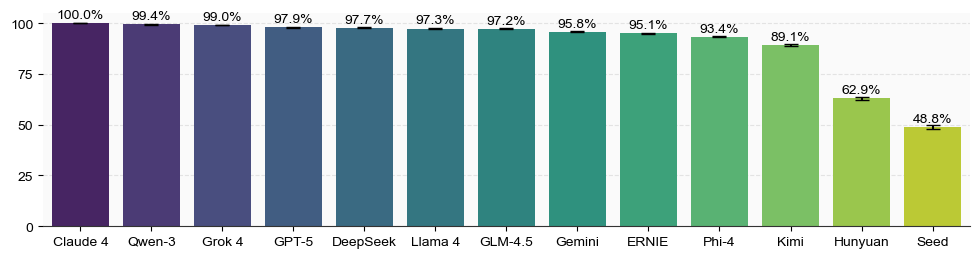

In [143]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Assuming 'model_results' and 'model_articles' are pre-loaded
# Reconstructing the dataframe as per the provided logic
valid_rates = model_results.size() / 1760 * 100 
valid_citations = model_articles.size()
structured_json_output_rate = pd.DataFrame({
    'valid_rates': valid_rates,
    'valid_citations': valid_citations,
    'std_errs': np.sqrt(valid_rates / 100 * (1 - valid_rates / 100) / valid_citations) * 100,   
    'ci95_errs': 1.96 * np.sqrt(valid_rates / 100 * (1 - valid_rates / 100) / valid_citations) * 100
})

structured_json_output_rate.sort_values('valid_rates', ascending=False, inplace=True)

plt.figure(figsize=(12*0.8, 3*0.8))

# Draw the barplot
ax = sns.barplot(x=structured_json_output_rate.index, 
                 y=structured_json_output_rate['valid_rates'], 
                 hue=structured_json_output_rate.index, 
                 palette="viridis", 
                 legend=False) # Bars are drawn here

# Add error bars
plt.errorbar(x=range(len(structured_json_output_rate)), 
             y=structured_json_output_rate['valid_rates'], 
             yerr=structured_json_output_rate['ci95_errs'], 
             fmt='none', c='black', capsize=5)

plt.ylabel("")
plt.xlabel("")

# Annotation loop
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2, p.get_height()+ 1), 
                ha='center', va='bottom', fontsize=10, color='black')
    
ax.set_yticks([0, 25, 50, 75, 100]) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.margins(x=0.01)

# --- KEY MODIFICATION START ---
# Force axis elements (grid and ticks) to be drawn below the plot elements
ax.set_axisbelow(True) 
ax.grid(True, axis='y', alpha=0.3)
# --- KEY MODIFICATION END ---

plt.tight_layout(pad=0)

if not os.path.exists('figs'):
    os.makedirs('figs')

plt.savefig('figs/structured_json_output_rate.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [144]:
# Save Structural Data Success Rate to report
structural_stats = {
    "Total Interactions": total_interactions,
    "Well-formed Interactions": len(results_df),
    "Well-formed Interaction Rate (%)": wellformed_interactions,
    "Total Citations": total_citations,
    "Well-formed Citations": len(articles_df),
    "Well-formed Citation Rate (%)": wellformed_citations,
    "Valid Citations": num_valid,
    "Hallucination Rate (%)": num_invalid / len(articles_df) * 100,
    "Invalid (Hallucinated) Citations": num_invalid,
    "Hallucination Rate (%)": num_invalid / len(articles_df) * 100
}

reporter.add_summary(
    "0. Structural Data Success Rate Analysis",
    structural_stats,
    "Overview of how many structurally valid citations were generated vs total attempts."
)

# Add model-wise performance table
model_perf_df = pd.DataFrame(model_metadata).T
model_perf_df.columns = ['JSONs Processed', 'Citations Processed', 'Valid Citations', 'Invalid Citations', 'Hallucination Rate (%)']
reporter.add_table(
    "Model-wise Performance Summary",
    model_perf_df.round(2),
    "Performance breakdown by model."
)

## 1. Overall Hallucination Rate by Model

Compare how different models perform in terms of citation validity.


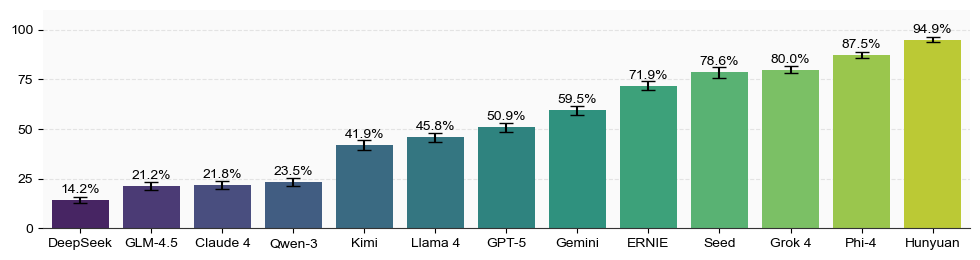

In [145]:
# Determine order
hallucination_rate = results_df.groupby('model')['hallucination_rate'].mean()
total_citations = results_df.groupby('model').size()
hallucination_df = pd.DataFrame({
    'hallucination_rate': hallucination_rate * 100,
    'total_citations': total_citations,
    'std_errs': np.sqrt(hallucination_rate * (1 - hallucination_rate) / total_citations) * 100,
    'ci95_errs': 1.96 * np.sqrt(hallucination_rate * (1 - hallucination_rate) / total_citations) * 100
})

hallucination_df.sort_values('hallucination_rate', ascending=True, inplace=True)

plt.figure(figsize=(12*0.8, 3*0.8))
# Use seaborn to aggregate and show error bars (95% CI by default)
ax = sns.barplot(x=hallucination_df.index, y=hallucination_df['hallucination_rate'], hue=hallucination_df.index, palette="viridis", legend=False)
plt.errorbar(x=range(len(hallucination_df)), y=hallucination_df['hallucination_rate'], yerr=hallucination_df['ci95_errs'], fmt='none', c='black', capsize=5)

plt.xlabel('')
plt.ylabel('')
plt.ylim(0, 110)

# 在每个bar上标注数值
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2, p.get_height()+2), 
                    ha='center', va='bottom', fontsize=10, color='black')

ax.set_yticks([0, 25, 50, 75, 100]) # 传入空列表，移除所有刻度点及对应数值
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.margins(x=0.01)

plt.tight_layout(pad=0)

# --- KEY MODIFICATION START ---
# Force axis elements (grid and ticks) to be drawn below the plot elements
ax.set_axisbelow(True) 
ax.grid(True, axis='y', alpha=0.3)
# --- KEY MODIFICATION END ---

import os
if not os.path.exists('figs'):
    os.makedirs('figs')
plt.savefig('figs/average_citation_hallucination_rate.pdf', dpi=300, bbox_inches='tight')

plt.show()

In [146]:
# Save Overall Hallucination Rate by Model to report
hallucination_report_df = hallucination_df.copy()
hallucination_report_df.columns = ['Hallucination Rate (%)', 'Total Citations', 'Std Error (%)', '95% CI Error (%)']
reporter.add_table(
    "1. Overall Citation Hallucination Rate by Model",
    hallucination_report_df.round(2),
    "Models ranked by average citation hallucination rate. Lower is better (fewer hallucinations)."
)

## 2. Impact of Online Searching and Thinking

Does "Online Searching" and "Thinking" (Chain of Thought) improve citation (reduce hallucinations)?


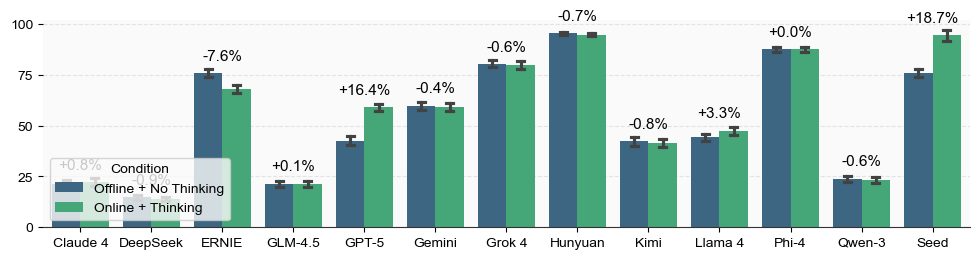

In [147]:
# Create a dataframe for plotting
plot_df = results_df.copy()
plot_df['hallucination_rate'] = plot_df['hallucination_rate'] * 100  # Percentage
plot_df['thinking_label'] = plot_df['thinking'].map({'thinking': 'Online + Thinking', 'nothinking': 'Offline + No Thinking'}).fillna(plot_df['thinking'])

# Compute means for difference annotation and ordering
model_thinking_means = plot_df.groupby(['model', 'thinking_label'])['hallucination_rate'].mean().reset_index()
models_sorted = sorted(plot_df['model'].unique())

plt.figure(figsize=(12*0.8, 3*0.8))
ax = sns.barplot(x='model', y='hallucination_rate', hue='thinking_label', data=plot_df, order=models_sorted, palette="viridis", capsize=.2)

plt.ylabel('')
plt.xlabel('')
ax.legend(title='Condition', loc='lower left')

# 计算差值并标注
for i, model in enumerate(models_sorted):
    group = model_thinking_means[model_thinking_means['model'] == model]
    if len(group) == 2:
        # Sort by label to match hue order roughly? 
        # Actually we want thinking - nothinking usually or vice versa.
        # Original code: group.iloc[1] - group.iloc[0]. 'Online' comes after 'Offline' alphabetically?
        # 'Online + Thinking', 'Offline + No Thinking'. 
        # 'Offline' is 0, 'Online' is 1 sorted.
        # So group.iloc[1] (Online) - group.iloc[0] (Offline).
        group = group.sort_values('thinking_label')
        val_online = group[group['thinking_label'] == 'Online + Thinking']['hallucination_rate'].values[0]
        val_offline = group[group['thinking_label'] == 'Offline + No Thinking']['hallucination_rate'].values[0]
        
        diff = val_online - val_offline  # Negative diff means online has lower hallucination (better)
        max_hallucination_rate = group['hallucination_rate'].max()
        # Add a little offset for error bar
        ax.annotate(f'{diff:+.1f}%', (i, max_hallucination_rate + 5), ha='center', va='bottom', fontsize=11, color='black')

ax.set_yticks([0, 25, 50, 75, 100]) # 传入空列表，移除所有刻度点及对应数值
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.margins(x=0.01)
plt.tight_layout(pad=0)

# --- KEY MODIFICATION START ---
# Force axis elements (grid and ticks) to be drawn below the plot elements
ax.set_axisbelow(True) 
ax.grid(True, axis='y', alpha=0.3)
# --- KEY MODIFICATION END ---


import os
if not os.path.exists('figs'):
    os.makedirs('figs')
plt.savefig('figs/impact_online_thinking.pdf', dpi=300, bbox_inches='tight')

plt.show()

In [148]:
# Save Impact of Online Searching and Thinking to report
thinking_impact_df = model_thinking_means.pivot(index='model', columns='thinking_label', values='hallucination_rate')
thinking_impact_df['Difference (Online - Offline)'] = thinking_impact_df['Online + Thinking'] - thinking_impact_df['Offline + No Thinking']
thinking_impact_df = thinking_impact_df.sort_values('Difference (Online - Offline)', ascending=False)

reporter.add_table(
    "2. Impact of Online Searching and Thinking Mode",
    thinking_impact_df.round(2),
    "Comparison of citation hallucination rates between online+thinking vs offline+no-thinking conditions. Negative difference indicates online search helps reduce hallucinations."
)

# Add summary statistics
thinking_summary = {
    "Average Online+Thinking Rate (%)": thinking_impact_df['Online + Thinking'].mean(),
    "Average Offline+NoThinking Rate (%)": thinking_impact_df['Offline + No Thinking'].mean(),
    "Average Improvement (%)": thinking_impact_df['Difference (Online - Offline)'].mean(),
    "Models Improved by Online Search": (thinking_impact_df['Difference (Online - Offline)'] > 0).sum(),
    "Models Degraded by Online Search": (thinking_impact_df['Difference (Online - Offline)'] < 0).sum()
}
reporter.add_summary("Online Search Impact Summary", thinking_summary)

## 3. Performance by Topic (Domain)

Which research fields have the highest hallucination rates?


       hallucination_rate  total_citations  std_errs  ci95_errs
topic                                                          
DL              80.185030              510  1.765055   3.459508
OH              75.381483              513  1.901974   3.727869
NI              73.417101              534  1.911741   3.747013
ET              69.377543              519  2.023233   3.965536
GT              64.044705              526  2.092330   4.100967
SY              63.902743              522  2.102140   4.120194
CY              62.237568              507  2.153041   4.219960
AR              60.586031              518  2.147071   4.208260
CE              60.577585              515  2.153396   4.220657
DB              60.307191              514  2.158037   4.229753
SE              60.259880              525  2.135743   4.186057
CR              59.963268              523  2.142501   4.199303
HC              59.507783              508  2.177914   4.268712
MM              59.195024              5

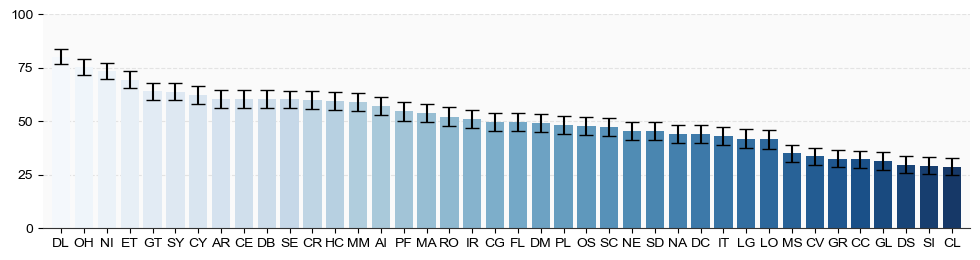

In [149]:

topic_order = results_df.groupby('topic')['hallucination_rate'].mean()
topic_citations_number = results_df.groupby('topic').size()

topic_df = pd.DataFrame({
    'hallucination_rate': topic_order * 100,
    'total_citations': topic_citations_number,
    'std_errs': np.sqrt(topic_order * (1 - topic_order) / topic_citations_number) * 100,
    'ci95_errs': 1.96 * np.sqrt(topic_order * (1 - topic_order) / topic_citations_number) * 100
})

topic_df.sort_values('hallucination_rate', ascending=False, inplace=True)

plt.figure(figsize=(12*0.8, 3*0.8))

# Plot with error bars
ax = sns.barplot(x=topic_df.index, y=topic_df['hallucination_rate'],
                hue=topic_df.index, palette="Blues")
plt.errorbar(x=range(len(topic_df)), y=topic_df['hallucination_rate'], yerr=topic_df['ci95_errs'], fmt='none', c='black', capsize=5)

plt.xlabel('')
plt.ylabel('')

ax.set_yticks([0, 25, 50, 75, 100]) # 传入空列表，移除所有刻度点及对应数值
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.margins(x=0.01)
plt.tight_layout(pad=0)

# --- KEY MODIFICATION START ---
# Force axis elements (grid and ticks) to be drawn below the plot elements
ax.set_axisbelow(True) 
ax.grid(True, axis='y', alpha=0.3)
# --- KEY MODIFICATION END ---

# for p in ax.patches:
#     ax.annotate(f'{p.get_height():.0f}%', 
#                 (p.get_x() + p.get_width() / 2, p.get_height()+3), 
#                 ha='center', va='bottom', fontsize=8, color='black')

print(topic_df)

import os
if not os.path.exists('figs'):
    os.makedirs('figs')
plt.savefig('figs/citation_hallucination_rate_by_topic.pdf', dpi=300, bbox_inches='tight')

plt.show()

In [150]:
# Save Performance by Topic to report
topic_report_df = topic_df.copy()
topic_report_df.columns = ['Hallucination Rate (%)', 'Total Citations', 'Std Error (%)', '95% CI Error (%)']
reporter.add_table(
    "3. Citation Hallucination Rate by Research Topic (Domain)",
    topic_report_df.round(2),
    "Topics ranked by average citation hallucination rate. Lower hallucination rate indicates the domain is easier for LLMs to generate valid citations."
)

# Add topic summary
topic_summary = {
    "Lowest Hallucination Topic": topic_report_df['Hallucination Rate (%)'].idxmin(),
    "Lowest Hallucination Rate (%)": topic_report_df['Hallucination Rate (%)'].min(),
    "Highest Hallucination Topic": topic_report_df['Hallucination Rate (%)'].idxmax(),
    "Highest Hallucination Rate (%)": topic_report_df['Hallucination Rate (%)'].max(),
    "Average Hallucination Rate (%)": topic_report_df['Hallucination Rate (%)'].mean(),
    "Std Dev of Hallucination Rates (%)": topic_report_df['Hallucination Rate (%)'].std()
}
reporter.add_summary("Topic/Domain Summary", topic_summary)

## 4. Scaling: Number of References

Does asking for more references (10 vs 20 vs 30) decrease the quality?


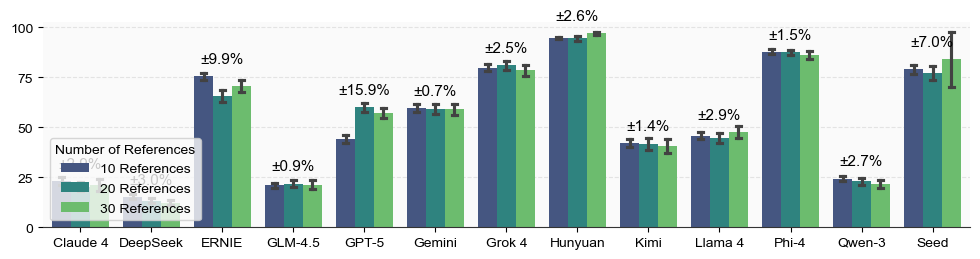

In [151]:
plot_df = results_df.copy()
plot_df['hallucination_rate'] = plot_df['hallucination_rate'] * 100
plot_df['num_refs_label'] = plot_df['num_refs'].map({
    10: '10 References',
    20: '20 References',
    30: '30 References'
})

# Calculate means for annotation
num_refs_means = plot_df.groupby(['model', 'num_refs_label'])['hallucination_rate'].mean().reset_index()
models_sorted = sorted(plot_df['model'].unique())

plt.figure(figsize=(12*0.8, 3*0.8))
ax = sns.barplot(x='model', y='hallucination_rate', hue='num_refs_label', data=plot_df, order=models_sorted, palette="viridis", capsize=.2)

plt.ylabel('')
plt.xlabel('')

# --- KEY MODIFICATION START ---
# Force axis elements (grid and ticks) to be drawn below the plot elements
ax.set_axisbelow(True) 
ax.grid(True, axis='y', alpha=0.3)
# --- KEY MODIFICATION END ---

ax.legend(title='Number of References', loc='lower left')

# 计算差值并标注
for i, model in enumerate(models_sorted):
    group = num_refs_means[num_refs_means['model'] == model]
    if len(group) == 3:
        max_val = group['hallucination_rate'].max()
        min_val = group['hallucination_rate'].min()
        diff = max_val - min_val
        # Offset slightly for error bars
        ax.annotate(f'±{diff:.1f}%', (i, max_val + 5), ha='center', va='bottom', fontsize=11, color='black')

ax.set_yticks([0, 25, 50, 75, 100]) # 传入空列表，移除所有刻度点及对应数值
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.margins(x=0.01)
plt.tight_layout(pad=0)

import os
if not os.path.exists('figs'):
    os.makedirs('figs')
plt.savefig('figs/effect_number_references.pdf', dpi=300, bbox_inches='tight')

plt.show()

In [152]:
# Save Scaling Analysis to report
scaling_pivot = num_refs_means.pivot(index='model', columns='num_refs_label', values='hallucination_rate')
scaling_pivot['Range (Max-Min)'] = scaling_pivot.max(axis=1) - scaling_pivot.min(axis=1)
scaling_pivot = scaling_pivot.sort_values('Range (Max-Min)', ascending=True)

reporter.add_table(
    "4. Effect of Number of References on Citation Validity",
    scaling_pivot.round(2),
    "Citation hallucination rate (%) when asking for different numbers of references. Lower range indicates more consistent performance across batch sizes."
)

# Add scaling summary
scaling_summary = {
    "Average Rate for 10 References (%)": num_refs_means[num_refs_means['num_refs_label'] == '10 References']['hallucination_rate'].mean(),
    "Average Rate for 20 References (%)": num_refs_means[num_refs_means['num_refs_label'] == '20 References']['hallucination_rate'].mean(),
    "Average Rate for 30 References (%)": num_refs_means[num_refs_means['num_refs_label'] == '30 References']['hallucination_rate'].mean(),
    "Most Stable Model": scaling_pivot['Range (Max-Min)'].idxmin(),
    "Least Stable Model": scaling_pivot['Range (Max-Min)'].idxmax()
}
reporter.add_summary("Scaling Analysis Summary", scaling_summary)

## 5. Each Model's Performance by Topic (Domain)

Will different models struggle in different research domains?

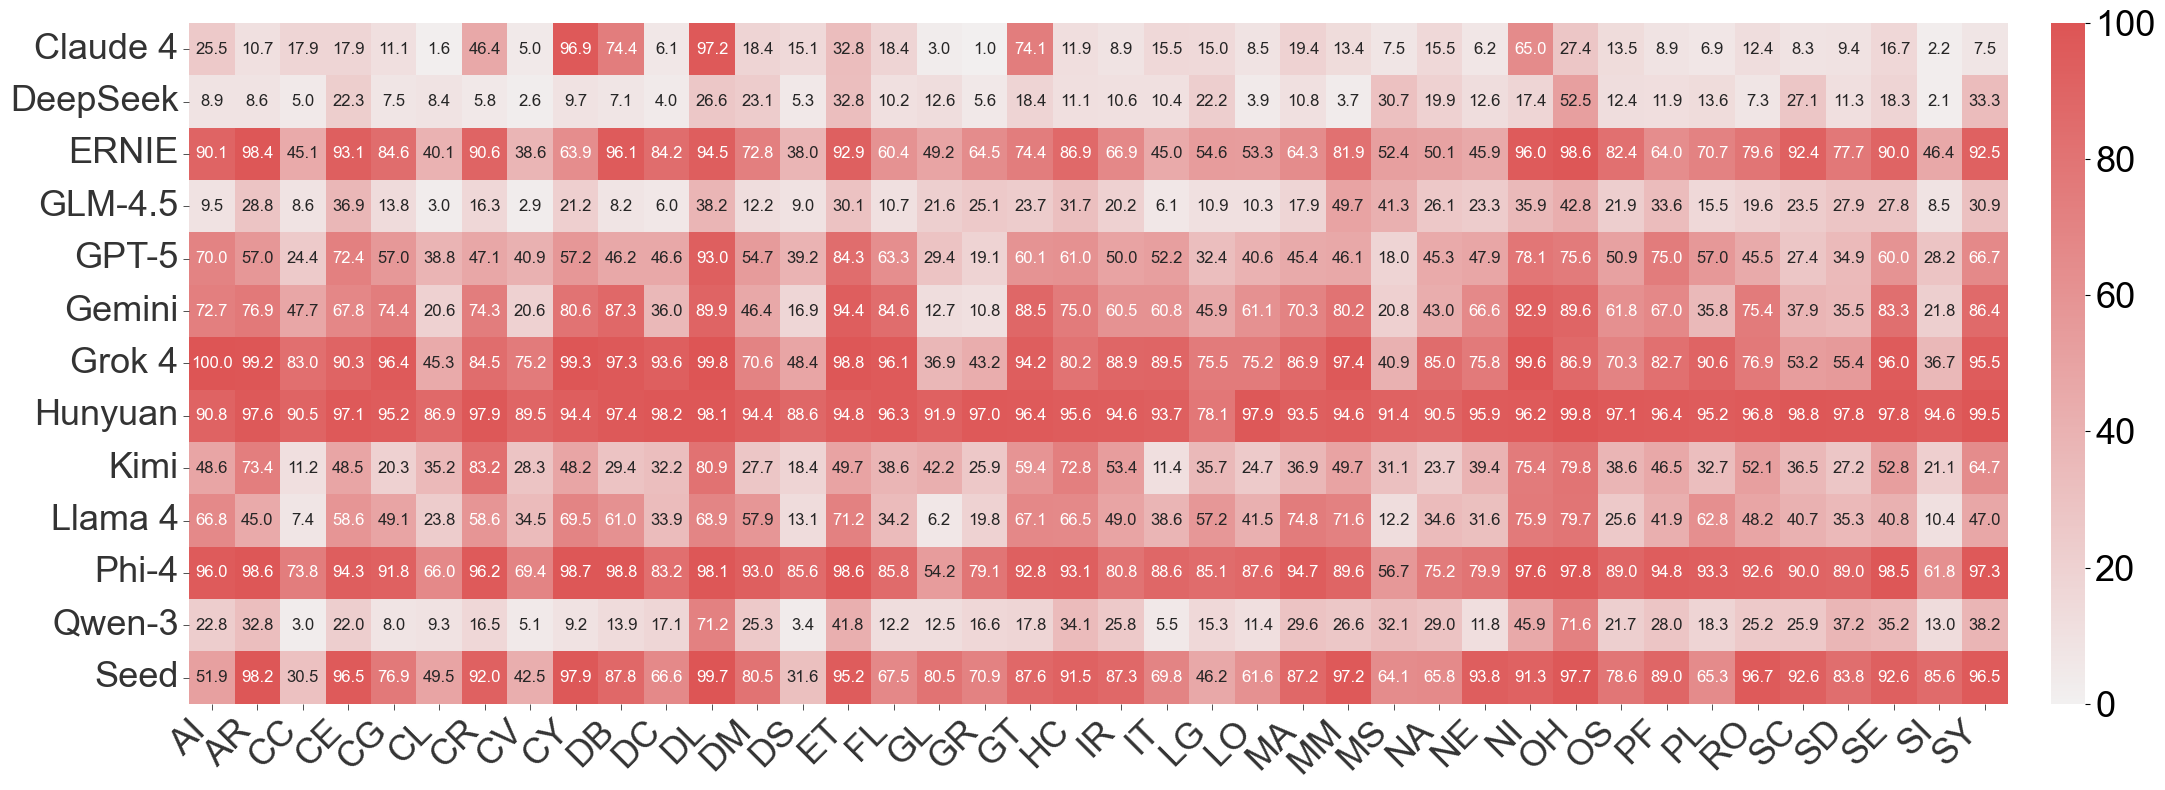

In [153]:
# 按模型和主题分组，计算平均hallucination_rate
model_topic_performance = results_df.groupby(['model', 'topic'])['hallucination_rate'].mean().reset_index()
model_topic_performance['hallucination_rate'] = model_topic_performance['hallucination_rate'] * 100  # 百分比

cmap = sns.light_palette("#DD5555", as_cmap=True, reverse=False)  # 红到白，红色可改成 #ff6b6b 等更亮
# cmap = truncate_colormap(cmap, 0.1, 1.0)
# 创建透视表用于热力图
pivot_table = model_topic_performance.pivot(index='model', columns='topic', values='hallucination_rate')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'axes.facecolor': '#FAFAFA',
    'figure.facecolor': 'white',
    'mathtext.fontset': 'stixsans',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
})
# 1. 强制使用无衬线字体 (Arial/Helvetica) 以匹配左图
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

# 获取原始 Reds
# original_cmap = plt.get_cmap('Reds')

plt.figure(figsize=(24, 8))
ax = sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap=cmap,
                 annot_kws={'fontsize': 12, "fontname": "Arial"},
                 cbar_kws={'label': '', 'pad': 0.02},
                 vmin=0, vmax=100)
ax.figure.axes[-1].tick_params(labelsize=14)  # 色条刻度字体
ax.set_facecolor('#FAFAFA')
plt.title('')
plt.xlabel('')
plt.ylabel('')
ax.figure.axes[-1].tick_params(labelsize=26)  # 色条刻度字体
plt.xticks(rotation=45, ha='right', fontsize=26)
plt.yticks(rotation=0, fontsize=26)
ax.tick_params(colors='#333333', length=4, width=0.6)
ax.margins(x=0.01)
plt.tight_layout()


import os
if not os.path.exists('figs'):
    os.makedirs('figs')
plt.savefig('figs/model_topic_heatmap.pdf', dpi=300, bbox_inches='tight')

plt.show()

In [154]:
# Save Model-Topic Performance Matrix to report
reporter.add_table(
    "5. Model Performance by Topic (Heatmap Data)",
    pivot_table.round(1),
    "Citation hallucination rate (%) for each model-topic combination. Lower values (closer to 0) indicate better performance."
)

# Find best and worst combinations
model_topic_flat = model_topic_performance.copy()
best_combo = model_topic_flat.loc[model_topic_flat['hallucination_rate'].idxmin()]  # Lower is better
worst_combo = model_topic_flat.loc[model_topic_flat['hallucination_rate'].idxmax()]  # Higher is worse

model_topic_summary = {
    "Best Model-Topic Combination": f"{best_combo['model']} on {best_combo['topic']}",
    "Best Combination Rate (%)": best_combo['hallucination_rate'],
    "Worst Model-Topic Combination": f"{worst_combo['model']} on {worst_combo['topic']}",
    "Worst Combination Rate (%)": worst_combo['hallucination_rate'],
    "Average Cross-Topic Variance by Model": pivot_table.var(axis=1).mean()
}
reporter.add_summary("Model-Topic Analysis Summary", model_topic_summary)

# 6. Detailed Analysis: Temporal, Author, and Consistency Analysis

We now dive deeper into the properties of the invalid citations (hallucinations).
1. **Temporal Distribution**: When do models think these hallucinations were published?
2. **Top Hallucinated Authors**: Whose names are most frequently used in fake citations?
3. **Hallucination Consistency**: Do models hallucinate the same fake papers across different runs?

In [155]:
# 6.1 Temporal Distribution of Citations
# Create counts_df for temporal analysis based on new_status (similarity_correct >= 0.9)

# Add validity status column based on is_valid (derived from new_status)
articles_df['validity_status'] = articles_df['is_valid'].apply(
    lambda x: 'Valid' if x else 'Hallucinated'
)

# Clean original_year: convert to string and filter valid 4-digit years
articles_df['original_year_clean'] = pd.to_numeric(articles_df['original_year'], errors='coerce')

# Filter articles with valid years (2000-2025)
valid_year_articles = articles_df[
    (articles_df['original_year_clean'].notna()) &
    (articles_df['original_year_clean'] >= 2000) &
    (articles_df['original_year_clean'] <= 2025)
].copy()

# Count citations by year and validity status
counts_df = valid_year_articles.groupby(['original_year_clean', 'validity_status']).size().reset_index(name='Count')
counts_df.columns = ['original_year', 'final_status', 'Count']

# Convert year to int for display
counts_df['original_year'] = counts_df['original_year'].astype(int)

print(f"Temporal distribution data created with {len(counts_df)} rows")
print(f"Valid year articles: {len(valid_year_articles)} out of {len(articles_df)}")
print(counts_df.head(10))

Temporal distribution data created with 52 rows
Valid year articles: 278400 out of 331809
   original_year  final_status  Count
0           2000  Hallucinated   1155
1           2000         Valid   3028
2           2001  Hallucinated   1675
3           2001         Valid   3244
4           2002  Hallucinated   1638
5           2002         Valid   3764
6           2003  Hallucinated   1610
7           2003         Valid   4063
8           2004  Hallucinated   1837
9           2004         Valid   3464


In [2]:
# 6.7 Word Cloud: LLM-Generated Title Keywords
%pip install wordcloud
from wordcloud import WordCloud, STOPWORDS

# Toggle to focus on hallucinated titles only
use_only_hallucinated = True

title_source = articles_df[~articles_df['is_valid']] if use_only_hallucinated else articles_df
titles = title_source['original_title'].dropna().astype(str).tolist()

raw_text = " ".join(titles).lower()
raw_text = re.sub(r"[^a-z0-9\s\-]", " ", raw_text)
tokens = [t for t in raw_text.split() if len(t) >= 3 and t not in STOPWORDS]
clean_text = " ".join(tokens)

if not clean_text.strip():
    raise ValueError("No valid tokens found for word cloud generation.")

wc = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    colormap="viridis",
    max_words=200,
    stopwords=STOPWORDS,
).generate(clean_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()

if not os.path.exists('figs'):
    os.makedirs('figs')
wc.to_file('figs/llm_title_wordcloud.png')

plt.show()

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/307.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/307.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/307.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/307.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/307.2 kB ? eta -:--:--
   --- ----------------------------------- 30.7/307.2 kB 163.8 kB/s eta 0:00:02
   ----- --------------------------------- 41.0/307.2 kB 150.6 kB/s eta 0:00:02
   ------- ------------------------------- 61.4/307.2 kB 217.9 kB/s eta 0:00:02
   ----------- --------------------------- 92.2/307.2 kB 261.7 kB/s eta 0:00:01
   ------------- ------------------------ 112.6/307.2 kB 311.2 kB/s eta 0:00:01
   ----------------- -------------------- 143.4/307.2 kB 340.5 kB/s eta 0:00:01
   --------------------- ---------------- 174.1/307.2 kB 374.1 kB/s eta 0:00:01
   -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


ModuleNotFoundError: No module named 'wordcloud'

In [156]:
# Save Temporal Distribution Analysis to report
temporal_pivot = counts_df.pivot(index='original_year', columns='final_status', values='Count').fillna(0)
temporal_pivot['Total'] = temporal_pivot.sum(axis=1)
temporal_pivot['Hallucination Rate (%)'] = (temporal_pivot['Hallucinated'] / temporal_pivot['Total'] * 100).round(2)

reporter.add_table(
    "6.1 Temporal Distribution of Citations",
    temporal_pivot,
    "Distribution of valid vs hallucinated citations by publication year (2000-2025)."
)

# Find peak years
temporal_summary = {
    "Year with Most Citations": temporal_pivot['Total'].idxmax(),
    "Peak Year Citation Count": int(temporal_pivot['Total'].max()),
    "Year with Highest Hallucination Rate": temporal_pivot['Hallucination Rate (%)'].idxmax(),
    "Highest Hallucination Rate (%)": temporal_pivot['Hallucination Rate (%)'].max(),
    "Year with Lowest Hallucination Rate": temporal_pivot[temporal_pivot['Total'] > 100]['Hallucination Rate (%)'].idxmin(),
    "Average Hallucination Rate (%)": temporal_pivot['Hallucination Rate (%)'].mean()
}
reporter.add_summary("Temporal Analysis Summary", temporal_summary)

拟合参数 (Parameters): a=239.05, b=0.199, c=878.40
拟合优度 (R^2 Score): 0.9446


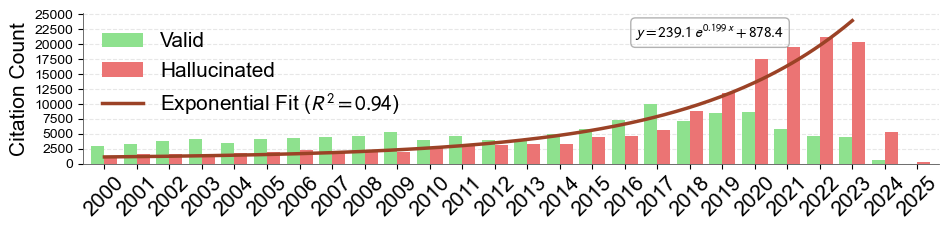

In [157]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# 假设 counts_df 已经按照您之前的代码生成，且列名为 'original_year', 'final_status', 'Count'

# 1. 数据准备 (Data Preparation for Fitting)
# 提取目标数据：2000-2023年的虚假文献 (Hallucinated)
fit_subset = counts_df[
    (counts_df['final_status'] == 'Hallucinated') & 
    (counts_df['original_year'].astype(int) >= 2000) & 
    (counts_df['original_year'].astype(int) <= 2023)
].copy()

# 转换数据类型并进行归一化 (Normalization)
x_raw = fit_subset['original_year'].astype(int).values
y_data = fit_subset['Count'].values
x_norm = x_raw - x_raw.min()  # 将2000年设为 t=0，避免数值溢出

# 2. 定义指数增长模型 (Exponential Growth Model Definition)
# 公式: y = a * e^(b * x) + c
def exponential_model(x, a, b, c):
    return a * np.exp(b * x) + c

# 3. 执行曲线拟合 (Execute Curve Fitting)
# p0为初始猜测值 (Initial Guess)，有助于算法收敛
try:
    popt, pcov = curve_fit(exponential_model, x_norm, y_data, p0=[1, 0.1, 0], maxfev=10000)
    a_fit, b_fit, c_fit = popt
    print(f"拟合参数 (Parameters): a={a_fit:.2f}, b={b_fit:.3f}, c={c_fit:.2f}")
except RuntimeError:
    print("拟合未能收敛 (Fitting failed to converge).")
    popt = None

# 4. 计算拟合优度 (Calculate Goodness of Fit - R^2)
if popt is not None:
    y_pred = exponential_model(x_norm, *popt)
    r2 = r2_score(y_data, y_pred)
    print(f"拟合优度 (R^2 Score): {r2:.4f}")
    # 平滑曲线用于绘图 (smooth curve for fitted line)
    x_smooth_norm = np.linspace(x_norm.min(), x_norm.max(), 200)
    y_smooth = exponential_model(x_smooth_norm, *popt)
    x_smooth_raw = x_smooth_norm + x_raw.min()

# --- KEY MODIFICATION START ---
# Force axis elements (grid and ticks) to be drawn below the plot elements
ax.set_axisbelow(True) 
ax.grid(True, axis='y', alpha=0.3)
# --- KEY MODIFICATION END ---


plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'axes.facecolor': '#FAFAFA',
    'figure.facecolor': 'white',
    'mathtext.fontset': 'stixsans',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
})
plt.figure(figsize=(12*0.8, 3*0.8))

# 论文统一色系 (Paper/color_palette.md)
PAPER_COLORS = {'primary': '#80EF80', 'primary_light': '#E8F4F8', 'alert': "#FF6060", 'alert_light': '#FFF0E6', 'alert_dark': '#9B4226', 'positive': '#2E7D32'}
# 绘制柱状图：Valid=主色，Hallucinated=警示色
ax = sns.barplot(
    data=counts_df, 
    x='original_year', 
    y='Count', 
    hue='final_status',
    hue_order=['Valid', 'Hallucinated'],
    palette={'Hallucinated': PAPER_COLORS['alert'], 'Valid': PAPER_COLORS['primary']},
    linewidth=0,
    edgecolor='#555555',
)

# 绘制拟合曲线 (Fitted Curve)
if popt is not None:
    # 注意：Barplot的x轴是Categorical的，直接plot需要转换坐标
    # 获取当前x轴的tick位置和标签，建立映射关系
    xticks_locs = ax.get_xticks()
    xticks_labels = [int(label.get_text()) for label in ax.get_xticklabels()]
    
    # 将平滑曲线的真实年份映射到barplot的x轴坐标系
    # 这里使用简单的线性插值将年份映射到索引位置
    x_plot_coords = np.interp(x_smooth_raw, xticks_labels, xticks_locs)
    
    # 拟合线：警示色深色 (alert_dark)，与 Hallucinated 柱同族
    plt.plot(x_plot_coords, y_smooth, color=PAPER_COLORS['alert_dark'], linewidth=2.5, linestyle='-', 
             label=f'Exponential Fit ($R^2={r2:.2f}$)')
    # 在图中标注拟合公式 y = a*e^(bx) + c
    formula_text = r'$y = {:.1f}\,e^{{{:.3f}\,x}} + {:.1f}$'.format(a_fit, b_fit, c_fit)
    ax.text(0.82, 0.94, formula_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='none', alpha=0.5, edgecolor='#666666'))

# 坐标轴与标签美化 (Aesthetic Refinement)
plt.xlabel('')
plt.ylabel('Citation Count', fontsize=15.2)
# 修改Xtick字体
plt.xticks(rotation=45,  fontsize=15.2)
# y 轴刻度更密
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=12))
# 图例
# 修改图例字体大小
# 方法一：直接指定 fontsize
# plt.legend(fontsize=16)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_color('#555555')
ax.spines['bottom'].set_linewidth(0.6)
ax.margins(x=0.01)

ax.set_axisbelow(True)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
# ax.grid(False)
ax.set_axis_on()
ax.patch.set_facecolor('#FFFFFF')

plt.tight_layout(pad=0)

# 图例：带细边框、无填充，更干净
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='', loc='upper left', frameon=False,
            facecolor="none",
          fancybox=False, fontsize=15)


plt.tight_layout()
# 6. 持久化存储 (Serialization)
if not os.path.exists('figs'):
    os.makedirs('figs')
plt.savefig('figs/temporal_distribution_barplot.pdf', dpi=300, bbox_inches='tight')

C:\Users\20532\AppData\Local\Temp\ipykernel_31632\3651861556.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=consistency_df, x='model', y='stability', order=model_order, palette='viridis', capsize=.1)


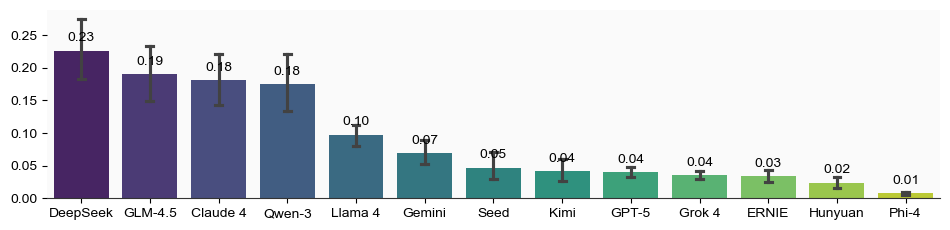

In [158]:
# 6.2 Hallucination Consistency (Stability)
# Metric: Stability = 1 - (Unique Invalid Titles / Total Invalid Titles) per (Model, Config) group
# If a model always hallucinates the same fake paper for the same prompt across runs, Stability -> 1.
# If it hallucinates random papers every time, Stability -> 0.

# Create a unique config identifier (excluding run)
articles_df['config_id'] = articles_df.apply(lambda x: f"{x['topic']}_refs_{x['thinking']}_{x['online']}", axis=1)

consistency_data = []

# Group by Model and ConfigID
grouped = articles_df.groupby(['model', 'config_id'])

for (model, config_id), group in grouped:
    # We analyze stability of INVALID citations (using is_valid based on similarity_correct >= 0.9)
    invalid_group = group[~group['is_valid']]
    
    if len(invalid_group) > 1:
        unique_titles = invalid_group['original_title'].str.strip().str.lower().nunique()
        total_invalid = len(invalid_group)
        
        stability = 1 - (unique_titles / total_invalid)
        
        consistency_data.append({
            'model': model,
            'stability': stability,
            'total_invalid': total_invalid,
            'config': config_id
        })

consistency_df = pd.DataFrame(consistency_data)

# Determine order
model_order = consistency_df.groupby('model')['stability'].mean().sort_values(ascending=False).index

# Higher = More Consistent/Repetitive Real Citations
plt.figure(figsize=(12*0.8, 3*0.8))
ax = sns.barplot(data=consistency_df, x='model', y='stability', order=model_order, palette='viridis', capsize=.1)
plt.ylabel('')
plt.xlabel('')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Annotate
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2, p.get_height() + 0.01), 
                    ha='center', va='bottom', fontsize=10, color='black')

plt.savefig('figs/hallucination_stability.pdf', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [159]:
# Save Hallucination Consistency Analysis to report
halluc_stability_summary = consistency_df.groupby('model')['stability'].agg(['mean', 'std', 'count']).round(3)
halluc_stability_summary.columns = ['Mean Stability', 'Std Dev', 'Config Count']
halluc_stability_summary = halluc_stability_summary.sort_values('Mean Stability', ascending=False)

reporter.add_table(
    "6.2 Hallucination Consistency (Stability) by Model",
    halluc_stability_summary,
    "Stability measures how consistently a model hallucinates the same fake papers. Higher stability (closer to 1) means the model repeatedly generates the same hallucinated citations."
)

halluc_stability_stats = {
    "Most Consistent Hallucinator": halluc_stability_summary['Mean Stability'].idxmax(),
    "Highest Stability Score": halluc_stability_summary['Mean Stability'].max(),
    "Least Consistent Hallucinator": halluc_stability_summary['Mean Stability'].idxmin(),
    "Lowest Stability Score": halluc_stability_summary['Mean Stability'].min(),
    "Average Stability Across Models": halluc_stability_summary['Mean Stability'].mean()
}
reporter.add_summary("Hallucination Stability Summary", halluc_stability_stats)

C:\Users\20532\AppData\Local\Temp\ipykernel_31632\3375159602.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=valid_consistency_df, x='model', y='stability', order=model_order, palette='viridis', capsize=.1)


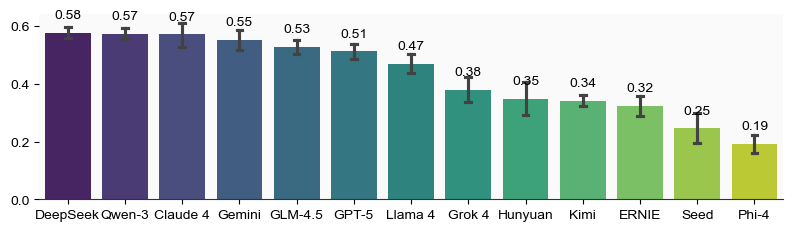

In [160]:
# 6.3 Valid Citation Stability
# Metric: Stability = 1 - (Unique Valid Titles / Total Valid Titles) per (Model, Config) group
# If a model always cites the same real paper for the same prompt across runs, Stability -> 1.
# If it cites different real papers every time, Stability -> 0.

valid_consistency_data = []

# Group by Model and ConfigID (already created above)
grouped = articles_df.groupby(['model', 'config_id'])

for (model, config_id), group in grouped:
    # We analyze stability of VALID citations (using is_valid based on similarity_correct >= 0.9)
    valid_group = group[group['is_valid']]
    
    if len(valid_group) > 1:
        unique_titles = valid_group['original_title'].str.strip().str.lower().nunique()
        total_valid = len(valid_group)
        
        stability = 1 - (unique_titles / total_valid)
        
        valid_consistency_data.append({
            'model': model,
            'stability': stability,
            'total_valid': total_valid,
            'config': config_id
        })

valid_consistency_df = pd.DataFrame(valid_consistency_data)

# Determine order
model_order = valid_consistency_df.groupby('model')['stability'].mean().sort_values(ascending=False).index

# Higher = More Consistent/Repetitive Real Citations
plt.figure(figsize=(12*0.8, 3*0.8))
ax = sns.barplot(data=valid_consistency_df, x='model', y='stability', order=model_order, palette='viridis', capsize=.1)
plt.ylabel('')
plt.xlabel('')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Annotate
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2, p.get_height()+.04), 
                    ha='center', va='bottom', fontsize=10, color='black')

plt.savefig('figs/valid_citation_stability.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [161]:
# 6.4 Most Frequently Cited Papers by Model and Topic
# For each model and topic, find the most commonly cited valid paper

# Filter for valid citations (using is_valid based on similarity_correct >= 0.9)
valid_articles = articles_df[articles_df['is_valid']].copy()

# Group by model and topic
grouped = valid_articles.groupby(['model', 'topic'])

most_cited = []

for (model, topic), group in grouped:
    if len(group) > 0:
        # Count occurrences of each title
        title_counts = group['original_title'].value_counts()
        if not title_counts.empty:
            top_title = title_counts.idxmax()
            top_count = title_counts.max()
            total_citations = len(group)
            percentage = (top_count / total_citations) * 100
            
            most_cited.append({
                'model': model,
                'topic': topic,
                'most_cited_title': top_title,
                'count': top_count,
                'total_valid': total_citations,
                'percentage': percentage
            })

most_cited_df = pd.DataFrame(most_cited)

# Display the results
print("Most Frequently Cited Papers by Model and Topic:")
most_cited_df.sort_values(['model', 'topic']).reset_index(drop=True)

Most Frequently Cited Papers by Model and Topic:


,model,topic,most_cited_title,count,total_valid,percentage
0,Claude 4,AI,DetectGPT: Zero-Shot Machine-Generated Text De...,40,553,7.233273
1,Claude 4,AR,SCNN: An Accelerator for Compressed-sparse Con...,28,651,4.301075
2,Claude 4,CC,Computers and Intractability: A Guide to the T...,43,581,7.401033
3,Claude 4,CE,A new deterministic spatio-temporal continuum ...,35,578,6.055363
4,Claude 4,CG,Fast Construction of Nets in Low-Dimensional M...,38,647,5.873261
...,...,...,...,...,...,...
514,Seed,SC,Gröbner Bases: A Computational Approach to Com...,2,20,10.000000
515,Seed,SD,Musical Genre Classification of Audio Signals,6,41,14.634146
516,Seed,SE,"Search-Based Software Testing: Trends, Techniq...",3,9,33.333333
517,Seed,SI,Social Network Analysis: Methods and Applications,3,41,7.317073


In [162]:
# Save Valid Citation Stability Analysis to report
valid_stability_summary = valid_consistency_df.groupby('model')['stability'].agg(['mean', 'std', 'count']).round(3)
valid_stability_summary.columns = ['Mean Stability', 'Std Dev', 'Config Count']
valid_stability_summary = valid_stability_summary.sort_values('Mean Stability', ascending=False)

reporter.add_table(
    "6.3 Valid Citation Stability by Model",
    valid_stability_summary,
    "Stability measures how consistently a model cites the same real papers. Higher stability means the model repeatedly cites the same valid references across runs."
)

valid_stability_stats = {
    "Most Consistent Valid Citer": valid_stability_summary['Mean Stability'].idxmax(),
    "Highest Stability Score": valid_stability_summary['Mean Stability'].max(),
    "Least Consistent Valid Citer": valid_stability_summary['Mean Stability'].idxmin(),
    "Lowest Stability Score": valid_stability_summary['Mean Stability'].min(),
    "Average Stability Across Models": valid_stability_summary['Mean Stability'].mean()
}
reporter.add_summary("Valid Citation Stability Summary", valid_stability_stats)

In [163]:
# # 6.5 Visualization of Most Frequently Cited Papers
# # Create a heatmap of percentage by model and topic, with abbreviated titles as annotations

# # Add abbreviated title for annotation
# most_cited_df['abbrev_title'] = most_cited_df['most_cited_title'].str[:30] + '...'

# # Pivot table for heatmap
# pivot_percentage = most_cited_df.pivot(index='model', columns='topic', values='percentage')
# pivot_titles = most_cited_df.pivot(index='model', columns='topic', values='abbrev_title')

# plt.figure(figsize=(20, 10))
# sns.heatmap(pivot_percentage, annot=pivot_titles, fmt='', cmap='Blues', cbar_kws={'label': 'Percentage (%)'})
# plt.title('Most Frequently Cited Papers by Model and Topic\n(Percentage of Valid Citations)')
# plt.xlabel('Research Topic')
# plt.ylabel('Model')

# plt.savefig('figs/most_cited_papers_heatmap.pdf', dpi=300, bbox_inches='tight')
# plt.show()

In [164]:
# 6.6 Most Frequently Cited Papers by Topic (Across All Models)
# Aggregate across all models, find the most cited paper per topic

# Filter for valid citations (using is_valid based on similarity_correct >= 0.9)
valid_articles = articles_df[articles_df['is_valid']].copy()

# Group by topic only
grouped_by_topic = valid_articles.groupby('topic')

most_cited_by_topic = []

for topic, group in grouped_by_topic:
    if len(group) > 0:
        # Count occurrences of each title across all models
        title_counts = group['original_title'].value_counts()
        if not title_counts.empty:
            top_title = title_counts.idxmax()
            top_count = title_counts.max()
            total_citations_in_topic = len(group)
            percentage = (top_count / total_citations_in_topic) * 100
            
            most_cited_by_topic.append({
                'topic': topic,
                'most_cited_title': top_title,
                'count': top_count,
                'total_valid_in_topic': total_citations_in_topic,
                'percentage': percentage
            })

most_cited_topic_df = pd.DataFrame(most_cited_by_topic)

# Display the results
print("Most Frequently Cited Papers by Topic (Across All Models):")
most_cited_topic_df.sort_values('topic').reset_index(drop=True)

Most Frequently Cited Papers by Topic (Across All Models):


,topic,most_cited_title,count,total_valid_in_topic,percentage
0,AI,Language Models are Few-Shot Learners,154,3595,4.283727
1,AR,Eyeriss: An Energy-Efficient Reconfigurable Ac...,184,3313,5.553879
2,CC,Computational Complexity: A Modern Approach,230,5649,4.071517
3,CE,A continuum multi-species biofilm model with a...,103,3266,3.153705
4,CG,Computational Geometry: Algorithms and Applica...,178,4252,4.186265
5,CL,Retrieval-Augmented Generation for Knowledge-I...,348,5575,6.242152
6,CR,A Method for Obtaining Digital Signatures and ...,91,3482,2.613441
7,CV,U-Net: Convolutional Networks for Biomedical I...,262,5425,4.829493
8,CY,Algorithms of Oppression: How Search Engines R...,114,3201,3.561387
9,DB,MapReduce: Simplified Data Processing on Large...,71,3412,2.080891


# 6.8 Model Overlap Analysis: Cross-Model Citation Sensitivity

This analysis examines the overlap of citations generated by different models. We create a heatmap where:
- Rows and columns represent different LLMs
- Cell values show the number of duplicate (shared) citations between each pair of models
- This helps identify which models tend to generate similar citations

正在构建稀疏矩阵...
正在进行向量化计算...
计算完成！正在绘图...
Heatmap saved to figs/cross-model_citation_full_matrix.pdf


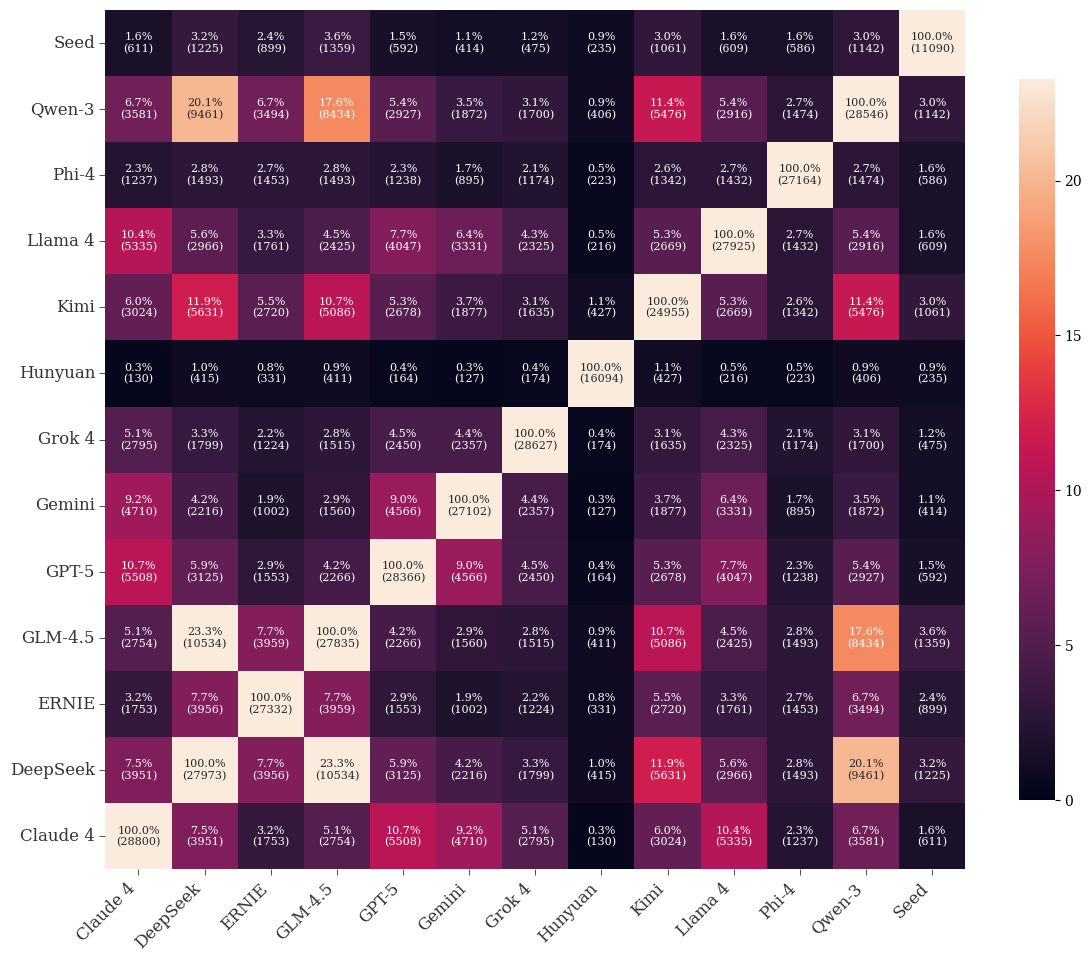

In [165]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import manhattan_distances
import os

# 假设 articles_df 已经加载

# 1. 数据预处理
# ------------------------------------------------------------------
print("正在构建稀疏矩阵...")
df_clean = articles_df[['model', 'original_title']].dropna()
df_clean['original_title'] = df_clean['original_title'].str.strip().str.lower()

model_groups = df_clean.groupby('model')['original_title'].apply(list)
models = sorted(model_groups.index.tolist())

# 2. 构建文档-词频矩阵
# ------------------------------------------------------------------
vectorizer = CountVectorizer(analyzer=lambda x: x)
X = vectorizer.fit_transform(model_groups)

# 3. 向量化计算 Extended Jaccard
# ------------------------------------------------------------------
print("正在进行向量化计算...")
model_total_counts = np.array(X.sum(axis=1)).flatten()
L1_matrix = manhattan_distances(X)

sum_matrix = model_total_counts[:, None] + model_total_counts[None, :]
intersection_matrix = 0.5 * (sum_matrix - L1_matrix)
union_matrix = sum_matrix - intersection_matrix

with np.errstate(divide='ignore', invalid='ignore'):
    jaccard_matrix = (intersection_matrix / union_matrix) * 100
    jaccard_matrix = np.nan_to_num(jaccard_matrix)

overlap_df = pd.DataFrame(intersection_matrix, index=models, columns=models).astype(int)
percentage_df = pd.DataFrame(jaccard_matrix, index=models, columns=models)

print("计算完成！正在绘图...")

# 4. 绘图 (全矩阵版本) — 风格化
# ------------------------------------------------------------------
plt.rcParams.update({
    'font.family': 'serif',
    'axes.facecolor': '#FAFAFA',
    'figure.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
})

# 创建注释矩阵
annot_matrix = pd.DataFrame(index=models, columns=models)
for i in range(len(models)):
    for j in range(len(models)):
        count = int(intersection_matrix[i, j])
        pct = jaccard_matrix[i, j]
        annot_matrix.iloc[i, j] = f"{pct:.1f}%\n({count})"

plt.figure(figsize=(12, 10))

# 计算 vmax (排除对角线以增强对比度)
off_diag_mask = ~np.eye(len(models), dtype=bool)
vmax_value = percentage_df.values[off_diag_mask].max()

# 绘制热力图
ax = sns.heatmap(percentage_df, 
                 annot=annot_matrix, 
                 fmt='', 
                 cmap='rocket',
                 square=True,
                 cbar_kws={'label': '', 'shrink': 0.8},
                 annot_kws={'size': 8},
                 vmin=0, vmax=vmax_value)

ax.invert_yaxis()
ax.set_facecolor('#FAFAFA')

plt.title('', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
ax.tick_params(colors='#333333', length=4, width=0.6)

if not os.path.exists('figs'):
    os.makedirs('figs')

plt.tight_layout()
plt.savefig('figs/cross-model_citation_full_matrix.pdf', dpi=300, bbox_inches='tight')

print(f"Heatmap saved to figs/cross-model_citation_full_matrix.pdf")
plt.show()

Heatmap saved to figs/cross-model_citation_overlap.pdf


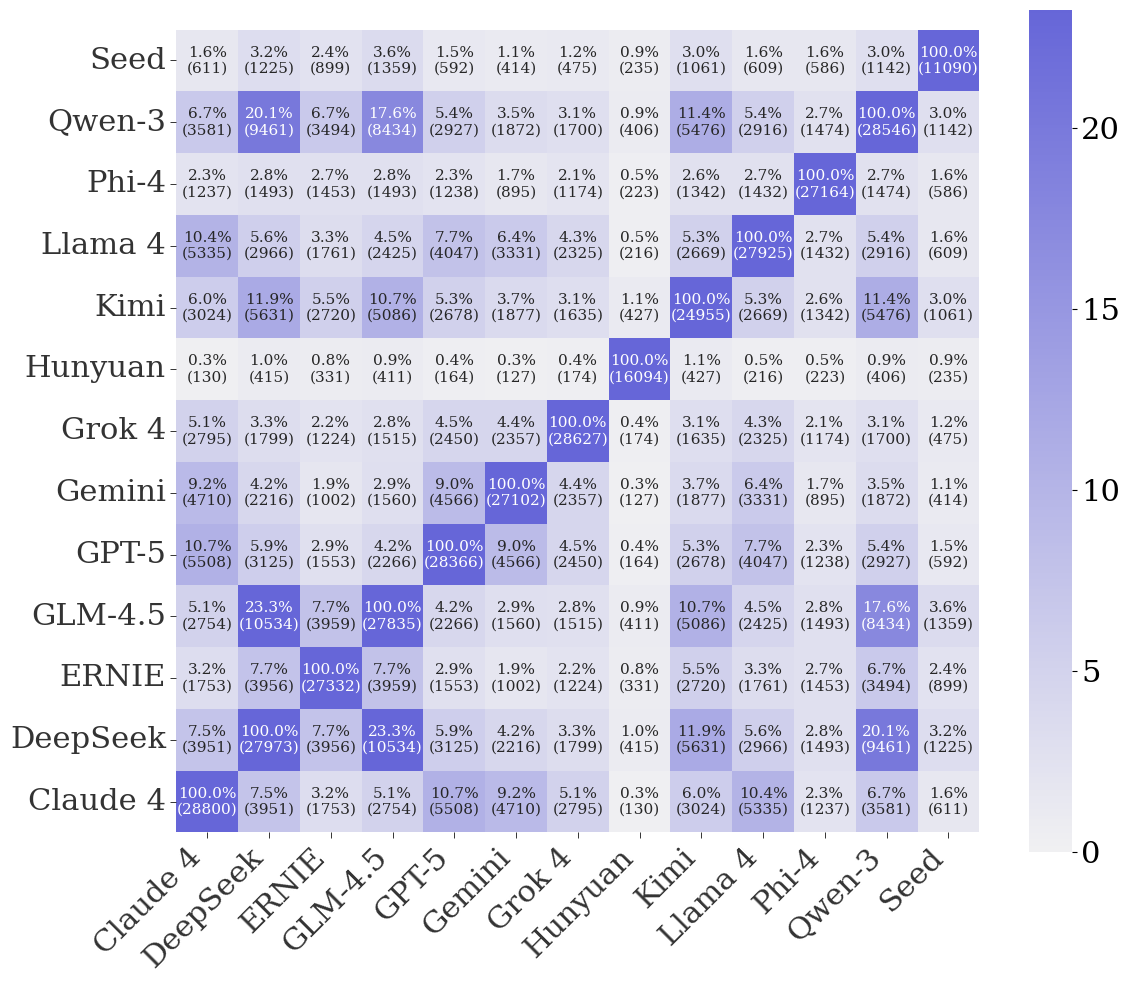

In [166]:
plt.figure(figsize=(12, 10))
import seaborn as sns
import matplotlib.colors as mcolors




# 获取原始 Reds
original_cmap = plt.get_cmap('Reds')

# 截断：去掉最浅的 10% (避免看不见) 和最深的 10% (避免覆盖文本)
custom_reds = truncate_colormap(original_cmap, 0, 0.7)

# cmap = sns.blend_palette(["#FFDDA6","#5959FF"], as_cmap=True,)
cmap = sns.light_palette("#6666D8", as_cmap=True, reverse=False)  # 红到白，红色可改成 #ff6b6b 等更亮

# 绘制热力图
ax = sns.heatmap(percentage_df, 
                 annot=annot_matrix, 
                 fmt='', 
                 cmap=cmap,
                 square=True,
                 cbar_kws={'label': ''},
                 annot_kws={'size': 11},
                 vmin=0, vmax=vmax_value)

ax.invert_yaxis()
ax.set_facecolor('#FAFAFA')

plt.title('', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
ax.figure.axes[-1].tick_params(labelsize=22)  # 色条刻度字体
plt.xticks(rotation=45, ha='right', fontsize=22)
plt.yticks(rotation=0, fontsize=22)
ax.tick_params(colors='#333333', length=4, width=0.7)

if not os.path.exists('figs'):
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2, p.get_height()+2), 
                    ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.savefig('figs/cross-model_citation_overlap.pdf', dpi=300, bbox_inches='tight')


print(f"Heatmap saved to figs/cross-model_citation_overlap.pdf")
plt.show()

In [167]:
# ... (在绘图代码之后)

# 计算每个模型与其他模型相似度的统计信息 (排除对角线自身 100%)
# ---------------------------------------------------------
stats = []
for i, model in enumerate(models):
    # 获取该模型那一行的所有数据
    row_values = jaccard_matrix[i, :]
    # 排除自己 (对角线位置)
    other_values = np.delete(row_values, i)
    
    stats.append({
        'Model': model,
        'Mean_Sim': np.mean(other_values),
        'SD_Sim': np.std(other_values),
        'Max_Sim': np.max(other_values),
        'Most_Similar_To': models[np.argmax(row_values)] if i != np.argmax(row_values) else models[np.argsort(row_values)[-2]] # 简单的逻辑取最大
    })

stats_df = pd.DataFrame(stats).sort_values('Mean_Sim', ascending=False)

print("\n=== 模型相似度分布摘要 (Model Similarity Distribution Stats) ===")
print(stats_df.to_string(formatters={
    'Mean_Sim': '{:.2f}%'.format,
    'SD_Sim': '{:.2f}'.format,
    'Max_Sim': '{:.2f}%'.format
}))


=== 模型相似度分布摘要 (Model Similarity Distribution Stats) ===
       Model Mean_Sim SD_Sim Max_Sim Most_Similar_To
1   DeepSeek    8.03%   6.72  23.27%         GLM-4.5
11    Qwen-3    7.20%   5.83  20.10%        DeepSeek
3    GLM-4.5    7.18%   6.51  23.27%        DeepSeek
8       Kimi    5.80%   3.47  11.91%        DeepSeek
0   Claude 4    5.66%   3.27  10.66%           GPT-5
4      GPT-5    4.97%   2.93  10.66%        Claude 4
9    Llama 4    4.82%   2.58  10.38%        Claude 4
5     Gemini    4.03%   2.76   9.20%        Claude 4
2      ERNIE    3.92%   2.26   7.73%         GLM-4.5
6     Grok 4    3.05%   1.35   5.12%        Claude 4
10     Phi-4    2.23%   0.66   2.79%         GLM-4.5
12      Seed    2.05%   0.90   3.62%         GLM-4.5
7    Hunyuan    0.66%   0.28   1.05%            Kimi


In [168]:
# Save Most Frequently Cited Papers by Topic to report
most_cited_report = most_cited_topic_df.copy()
most_cited_report = most_cited_report.sort_values('percentage', ascending=False)
most_cited_report.columns = ['Topic', 'Most Cited Title', 'Citation Count', 'Total Valid in Topic', 'Percentage (%)']
most_cited_report = most_cited_report.set_index('Topic')

reporter.add_table(
    "6.6 Most Frequently Cited Papers by Topic",
    most_cited_report.round(2),
    "For each research topic, the most commonly cited valid paper across all models. High percentage indicates strong consensus among models about key references in that field."
)

# 7. Export Analysis Results to Markdown

This section exports all analysis results to a Markdown file for documentation and reporting purposes.

## 7.1 Append Additional Sections

This cell adds additional sections to the markdown report including:
- Most frequently cited papers by topic
- List of generated figures

In [169]:
# Save the analysis report to markdown file
output_path = reporter.save("analysis_results.md")
print(f"\nMarkdown report generated successfully!")
print(f"Total sections: {len(reporter.sections)}")
print(f"Output file: {output_path}")
print("\nSections included in the report:")
for i, section in enumerate(reporter.sections, 1):
    print(f"  {i}. {section['title']}")

Report saved to: analysis_results.md

Markdown report generated successfully!
Total sections: 18
Output file: analysis_results.md

Sections included in the report:
  1. 0. Structural Data Success Rate Analysis
  2. Model-wise Performance Summary
  3. 1. Overall Citation Hallucination Rate by Model
  4. 2. Impact of Online Searching and Thinking Mode
  5. Online Search Impact Summary
  6. 3. Citation Hallucination Rate by Research Topic (Domain)
  7. Topic/Domain Summary
  8. 4. Effect of Number of References on Citation Validity
  9. Scaling Analysis Summary
  10. 5. Model Performance by Topic (Heatmap Data)
  11. Model-Topic Analysis Summary
  12. 6.1 Temporal Distribution of Citations
  13. Temporal Analysis Summary
  14. 6.2 Hallucination Consistency (Stability) by Model
  15. Hallucination Stability Summary
  16. 6.3 Valid Citation Stability by Model
  17. Valid Citation Stability Summary
  18. 6.6 Most Frequently Cited Papers by Topic
